# Group01_Dataset_task2_baselines

## Task 2 – Baseline Machine Learning Models

**Dataset:** GRABMyo

**Goal:**

Establish baseline performance for surface EMG gesture recognition using handcrafted statistical features extracted from the GRABMyo dataset.

The notebook performs:

- Feature loading and preprocessing
- Subject-independent train–test splitting
- Feature standardization
- Training and evaluation of multiple baseline machine learning models:
  - Random Forest
  - Decision Tree
  - K-Nearest Neighbors (KNN)
  - Support Vector Machine (SVM)
  - Multi-Layer Perceptron (MLP)
- Performance comparison using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and Training Time
- Selection of the strongest baseline model for comparison with the proposed Graph Neural Network (GNN) model

# Imports

In [1]:
!pip install wfdb -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.4 MB/s eta 0:00:0000:0100:01


In [2]:
import wfdb

from sklearn.model_selection import GroupShuffleSplit

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

import time

# Set Dataset Path

In [3]:
DATASET = "/kaggle/input/datasets/raihanbd/grabmyopc"

# Find All Recordings

Remember:

Each recording has

.dat
.hea

We only need the .hea files because wfdb.rdrecord() reads both automatically.

In [4]:
import glob

hea_files = sorted(
    glob.glob(DATASET + "/**/*.hea", recursive=True)
)

print("Total recordings:", len(hea_files))

Total recordings: 15351


# Let's inspect one file

In [5]:
print(hea_files[0])

/kaggle/input/datasets/raihanbd/grabmyopc/Session1/session1_participant1/session1_participant1_gesture10_trial1.hea


# Create Feature Function

This is the heart of Task 2.

For ONE recording

↓

Read signal

↓

Calculate features

↓

Return one feature vector

In [6]:
from scipy.stats import skew, kurtosis
import numpy as np
import wfdb

def extract_features(record_path):

    record = wfdb.rdrecord(record_path)

    signal = record.p_signal

    features = []

    for ch in range(signal.shape[1]):

        x = signal[:, ch]

        features.extend([

            np.mean(x),

            np.std(x),

            np.sqrt(np.mean(x**2)),      # RMS

            np.max(x),

            np.min(x),

            skew(x),

            kurtosis(x)

        ])

    return features

# Test on ONE Recording

Don't process all 15,351 yet.

Test first.

In [7]:
sample = hea_files[0].replace(".hea", "")

fv = extract_features(sample)

print("Number of features:", len(fv))

print(fv[:15])

Number of features: 224
[np.float64(-7.370008983383674e-06), np.float64(0.04792535856427061), np.float64(0.04792535913095424), np.float64(0.2601355851155616), np.float64(-0.33984347953065613), np.float64(-0.2646546284459511), np.float64(2.5740332215837505), np.float64(1.0909487730021528e-05), np.float64(0.06436716330966509), np.float64(0.06436716423418092), np.float64(0.3699681664418466), np.float64(-0.4013716745885394), np.float64(-0.26817014315825055), np.float64(2.737364979536131), np.float64(1.585116344749272e-05)]


# Build the Feature Dataset

We will process every recording and save:

224 extracted features
Gesture label
Participant ID

In [8]:
import re

all_features = []

for i, file in enumerate(hea_files):

    record_path = file.replace(".hea", "")

    # Extract features
    features = extract_features(record_path)

    # Extract gesture number
    gesture = int(re.search(r'gesture(\d+)', file).group(1))

    # Extract participant number
    participant = re.search(r'participant(\d+)', file).group(1)

    # Save everything
    features.append(gesture)
    features.append(participant)

    all_features.append(features)

    # Progress update every 500 recordings
    if (i + 1) % 500 == 0:
        print(f"Processed {i+1}/{len(hea_files)} recordings")

Processed 500/15351 recordings
Processed 1000/15351 recordings
Processed 1500/15351 recordings
Processed 2000/15351 recordings
Processed 2500/15351 recordings
Processed 3000/15351 recordings
Processed 3500/15351 recordings
Processed 4000/15351 recordings
Processed 4500/15351 recordings
Processed 5000/15351 recordings
Processed 5500/15351 recordings
Processed 6000/15351 recordings
Processed 6500/15351 recordings
Processed 7000/15351 recordings
Processed 7500/15351 recordings
Processed 8000/15351 recordings
Processed 8500/15351 recordings
Processed 9000/15351 recordings
Processed 9500/15351 recordings
Processed 10000/15351 recordings
Processed 10500/15351 recordings
Processed 11000/15351 recordings
Processed 11500/15351 recordings
Processed 12000/15351 recordings
Processed 12500/15351 recordings
Processed 13000/15351 recordings
Processed 13500/15351 recordings
Processed 14000/15351 recordings
Processed 14500/15351 recordings
Processed 15000/15351 recordings


# Create DataFrame

After the loop finishes:

In [15]:
import pandas as pd

feature_names = []

channels = [
    'F1','F2','F3','F4','F5','F6','F7','F8',
    'F9','F10','F11','F12','F13','F14','F15','F16',
    'U1','W1','W2','W3','W4','W5','W6',
    'U2','U3',
    'W7','W8','W9','W10','W11','W12',
    'U4'
]

stats = [
    "mean",
    "std",
    "rms",
    "max",
    "min",
    "skew",
    "kurtosis"
]

for ch in channels:
    for s in stats:
        feature_names.append(f"{ch}_{s}")

feature_names += ["Gesture", "Participant"]

features_df = pd.DataFrame(
    all_features,
    columns=feature_names
)

print(features_df.shape)

features_df.head()



(15351, 226)


,F1_mean,F1_std,F1_rms,F1_max,F1_min,F1_skew,F1_kurtosis,F2_mean,F2_std,F2_rms,...,W12_kurtosis,U4_mean,U4_std,U4_rms,U4_max,U4_min,U4_skew,U4_kurtosis,Gesture,Participant
0,-0.000007,0.047925,0.047925,0.260136,-0.339843,-0.264655,2.574033,1.090949e-05,0.064367,0.064367,...,3.683970,-0.000007,0.005259,0.005259,0.024637,-0.018634,0.068160,0.030816,10,1
1,0.000042,0.057235,0.057235,0.468627,-0.762632,-1.051270,16.942218,5.478721e-05,0.070744,0.070744,...,7.672553,0.000004,0.005121,0.005121,0.020376,-0.018360,0.062297,0.018950,10,1
2,0.000031,0.039620,0.039620,0.203892,-0.318856,-0.634328,3.795827,4.641456e-05,0.049239,0.049239,...,2.516949,0.000006,0.005027,0.005027,0.021722,-0.016988,0.032977,-0.050155,10,1
3,0.000005,0.068228,0.068228,0.448661,-0.577181,-0.588082,6.938354,1.154374e-05,0.080734,0.080734,...,2.347303,0.000004,0.005212,0.005212,0.021255,-0.019441,0.066974,0.043904,10,1
4,0.000005,0.060540,0.060540,0.292897,-0.504235,-0.421295,2.379207,9.085645e-07,0.075170,0.075170,...,4.008699,0.000006,0.005151,0.005151,0.021032,-0.019224,0.098694,0.096034,10,1


# Check info

In [13]:
features_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15351 entries, 0 to 15350
Columns: 226 entries, F1_mean to Participant
dtypes: float64(224), int64(1), object(1)
memory usage: 26.5+ MB


# Missing values

In [16]:
features_df.isnull().sum().sum()

np.int64(0)

# Gesture distribution

In [17]:
features_df["Gesture"].value_counts().sort_index()

Gesture
1     903
2     903
3     903
4     903
5     903
6     903
7     903
8     903
9     903
10    903
11    903
12    903
13    903
14    903
15    903
16    903
17    903
Name: count, dtype: int64

# Participant count

In [18]:
features_df["Participant"].nunique()

43

# Copy of features_df = model_df

✅ features_df = original extracted-feature dataset

✅ model_df = dataset used for ML experiments

In [19]:
model_df = features_df.copy()

# Separate Features, Label, and Groups

What are these?

X → 224 extracted features

y → Gesture class (1–17)

groups → Participant IDs (used for subject-wise split)

In [20]:
X = model_df.drop(columns=["Gesture", "Participant"])

y = model_df["Gesture"]

groups = model_df["Participant"]

# Subject-wise Train/Test Split

This is mandatory according to project instructions.



Where is the validation set?

At the moment, we have only:

Whole Dataset

Training Set (80%)

Testing Set (20%)


For the baseline models (Random Forest, SVM, KNN, Decision Tree, MLP), 

this is completely fine.


A validation set is mainly needed 

when you're tuning many hyperparameters or training 

deep learning models like 1D CNN and GNN.


For Task 2, the common workflow is:

Dataset
   Train (80%)
   Test (20%)


Later, when we build the 1D CNN and especially the Graph Neural Network, we'll split the training data again:

Dataset
   
   Train
   
   Validation
   
   Test


The validation set helps decide things like the best number of epochs or when to stop training.

So for now:

✅ Train set → learn the model

✅ Test set → evaluate the final performance

⏳ Validation set → we'll add it later for the neural network models.

In [21]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

# Verify the Split

In [22]:
print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

print()

print("Training participants :", groups_train.nunique())
print("Testing participants  :", groups_test.nunique())

print()

print("Participants in both sets:",
      len(set(groups_train) & set(groups_test)))

Training samples : 12138
Testing samples  : 3213

Training participants : 34
Testing participants  : 9

Participants in both sets: 0


⭐No participant appears in both datasets.

⭐This satisfies your professor's no leakage requirement.  

# Standardize the Features

X_train_scaled and X_test_scaled


Now every feature has roughly

Mean ≈ 0

Std ≈ 1

This helps SVM, KNN and MLP.

(Random Forest doesn't require scaling, 

but using the same scaled data for all baselines 

is acceptable and keeps the pipeline consistent.)

In [23]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Check Shapes

In [24]:
print("X_train :", X_train_scaled.shape)
print("X_test  :", X_test_scaled.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (12138, 224)
X_test  : (3213, 224)
y_train : (12138,)
y_test  : (3213,)


Your professor wrote:

Run baselines → compare → name the baseline to beat → then design your proposed GNN.

So the baseline should be simple and fair, not heavily optimized.

What we are doing now

✅ Use the 224 extracted features.

✅ Use the subject-wise split (very important).

✅ Apply standard preprocessing.

✅ Train Random Forest with reasonable default settings (n_estimators=100).

✅ Record the results.

This gives you an honest baseline.

In [44]:
results = []

# training function

In [45]:
def train_and_evaluate(model, model_name):

    print("\n" + "="*70)
    print(f"{model_name}")
    print("="*70)

    # Train
    start = time.time()

    model.fit(X_train_scaled, y_train)

    train_time = time.time() - start

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    # Print results
    print(f"Accuracy      : {accuracy:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1-score      : {f1:.4f}")
    print(f"Training Time : {train_time:.2f} seconds")

    print("\nClassification Report\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(10,8))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    print(cm)

    plt.show()

    # Save results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "Training Time (s)": train_time
    })

# Random Forest

What do these parameters mean?

n_estimators=100 → Build 100 decision trees.

random_state=42 → Gives the same result every run.

n_jobs=-1 → Uses all CPU cores to train faster.


Random Forest
Accuracy      : 0.5795
Precision     : 0.5946
Recall        : 0.5795
F1-score      : 0.5809
Training Time : 10.78 seconds

Classification Report

              precision    recall  f1-score   support

           1       0.48      0.40      0.44       189
           2       0.25      0.33      0.29       189
           3       0.50      0.38      0.43       189
           4       0.40      0.36      0.38       189
           5       0.54      0.39      0.45       189
           6       0.76      0.66      0.71       189
           7       0.39      0.57      0.46       189
           8       0.58      0.69      0.63       189
           9       0.49      0.46      0.47       189
          10       0.59      0.58      0.59       189
          11       0.78      0.80      0.79       189
          12       0.81      0.75      0.78       189
          13       0.78      0.50      0.61       189
          14       0.76      0.71      0.74       189
          15       0.60     

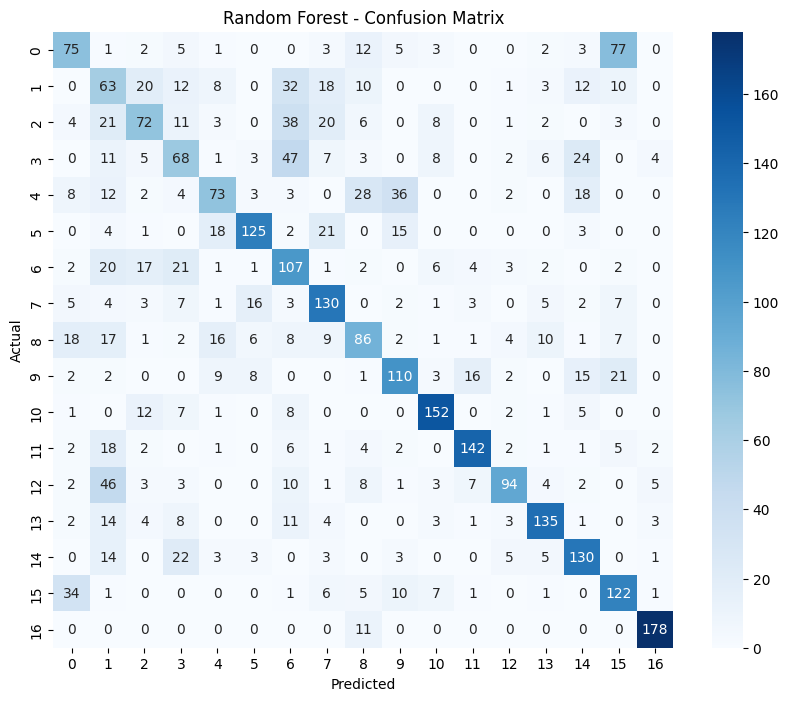

In [46]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

train_and_evaluate(rf, "Random Forest")

# Decision Tree


Decision Tree
Accuracy      : 0.3623
Precision     : 0.3773
Recall        : 0.3623
F1-score      : 0.3659
Training Time : 7.52 seconds

Classification Report

              precision    recall  f1-score   support

           1       0.27      0.33      0.30       189
           2       0.14      0.15      0.15       189
           3       0.23      0.21      0.22       189
           4       0.22      0.24      0.23       189
           5       0.35      0.34      0.34       189
           6       0.40      0.39      0.39       189
           7       0.23      0.28      0.25       189
           8       0.36      0.38      0.37       189
           9       0.30      0.21      0.25       189
          10       0.29      0.24      0.26       189
          11       0.80      0.63      0.70       189
          12       0.48      0.34      0.40       189
          13       0.37      0.28      0.32       189
          14       0.46      0.49      0.47       189
          15       0.37      

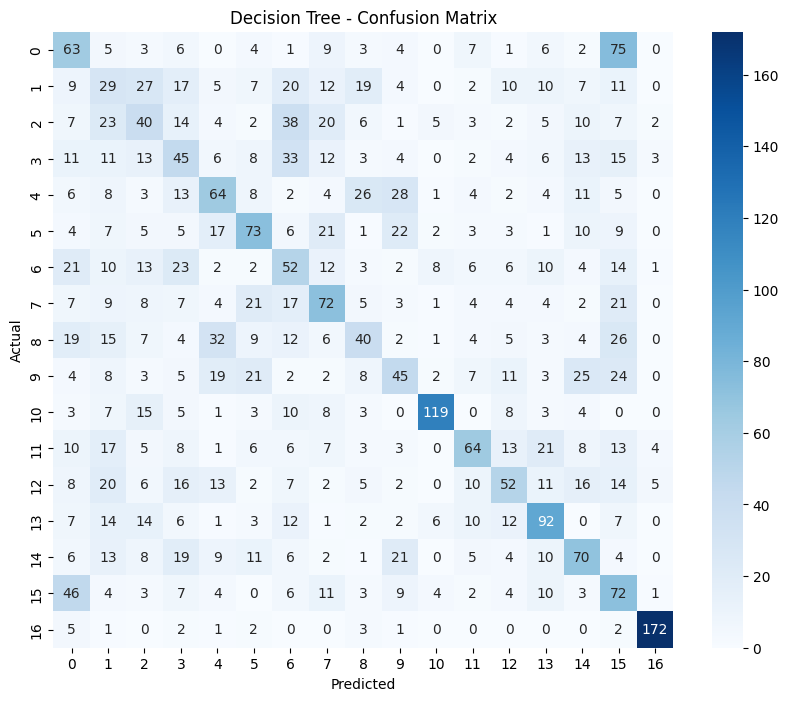

In [47]:
dt = DecisionTreeClassifier(
    random_state=42
)

train_and_evaluate(dt, "Decision Tree")

# KNN


K-Nearest Neighbors
Accuracy      : 0.4040
Precision     : 0.4592
Recall        : 0.4040
F1-score      : 0.4165
Training Time : 0.01 seconds

Classification Report

              precision    recall  f1-score   support

           1       0.25      0.44      0.32       189
           2       0.18      0.37      0.24       189
           3       0.23      0.35      0.27       189
           4       0.23      0.28      0.25       189
           5       0.37      0.26      0.31       189
           6       0.49      0.33      0.39       189
           7       0.25      0.37      0.30       189
           8       0.40      0.28      0.33       189
           9       0.40      0.26      0.31       189
          10       0.46      0.33      0.38       189
          11       0.79      0.74      0.76       189
          12       0.78      0.41      0.54       189
          13       0.44      0.41      0.42       189
          14       0.75      0.42      0.54       189
          15       0.49

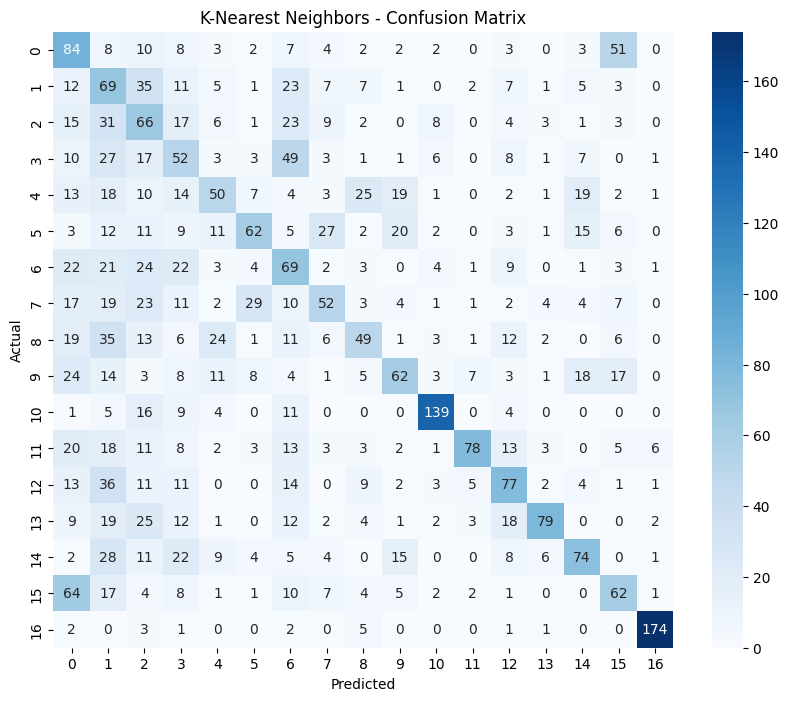

In [48]:
knn = KNeighborsClassifier(
    n_neighbors=5
)

train_and_evaluate(knn, "K-Nearest Neighbors")

# SVM


Support Vector Machine
Accuracy      : 0.5954
Precision     : 0.6180
Recall        : 0.5954
F1-score      : 0.6002
Training Time : 9.89 seconds

Classification Report

              precision    recall  f1-score   support

           1       0.47      0.53      0.50       189
           2       0.26      0.35      0.30       189
           3       0.47      0.34      0.39       189
           4       0.40      0.42      0.41       189
           5       0.56      0.48      0.51       189
           6       0.77      0.68      0.72       189
           7       0.38      0.50      0.43       189
           8       0.49      0.72      0.59       189
           9       0.51      0.44      0.47       189
          10       0.66      0.58      0.62       189
          11       0.87      0.79      0.83       189
          12       0.89      0.77      0.82       189
          13       0.87      0.54      0.67       189
          14       0.80      0.74      0.77       189
          15       0

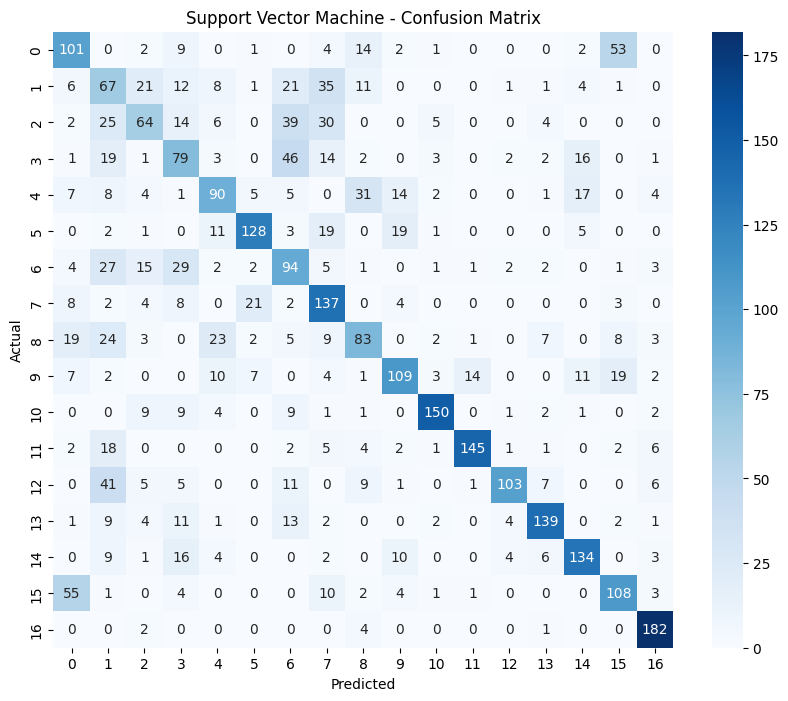

In [49]:
svm = SVC(
    kernel="rbf",
    random_state=42
)

train_and_evaluate(svm, "Support Vector Machine")

# MLP


Multi-Layer Perceptron
Accuracy      : 0.6197
Precision     : 0.6362
Recall        : 0.6197
F1-score      : 0.6208
Training Time : 31.60 seconds

Classification Report

              precision    recall  f1-score   support

           1       0.47      0.59      0.52       189
           2       0.41      0.33      0.37       189
           3       0.58      0.39      0.47       189
           4       0.42      0.51      0.46       189
           5       0.60      0.57      0.58       189
           6       0.69      0.66      0.67       189
           7       0.47      0.51      0.49       189
           8       0.47      0.77      0.58       189
           9       0.52      0.40      0.45       189
          10       0.68      0.61      0.64       189
          11       0.99      0.72      0.84       189
          12       0.85      0.75      0.80       189
          13       0.81      0.66      0.72       189
          14       0.79      0.75      0.77       189
          15       

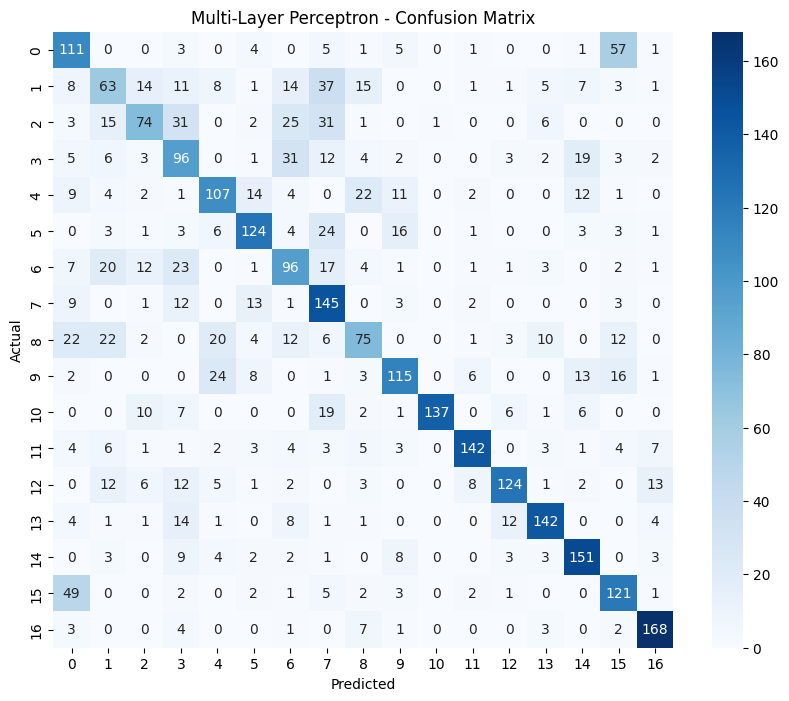

In [50]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42
)

train_and_evaluate(mlp, "Multi-Layer Perceptron")

# Final Comparison Table

In [51]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df = results_df.round(4)

results_df

,Model,Accuracy,Precision,Recall,F1-score,Training Time (s)
4,Multi-Layer Perceptron,0.6197,0.6362,0.6197,0.6208,31.6012
3,Support Vector Machine,0.5954,0.6180,0.5954,0.6002,9.8852
0,Random Forest,0.5795,0.5946,0.5795,0.5809,10.7796
2,K-Nearest Neighbors,0.4040,0.4592,0.4040,0.4165,0.0118
1,Decision Tree,0.3623,0.3773,0.3623,0.3659,7.5165


# BEST BASELINE MODEL = MLP (Multi-Layer Perceptron)

In [53]:
print("\n" + "="*70)
print("BEST BASELINE MODEL")
print("="*70)

print(f"Model      : {results_df.iloc[0]['Model']}")
print(f"Accuracy   : {results_df.iloc[0]['Accuracy']:.4f}")
print(f"Precision  : {results_df.iloc[0]['Precision']:.4f}")
print(f"Recall     : {results_df.iloc[0]['Recall']:.4f}")
print(f"F1-score   : {results_df.iloc[0]['F1-score']:.4f}")


BEST BASELINE MODEL
Model      : Multi-Layer Perceptron
Accuracy   : 0.6197
Precision  : 0.6362
Recall     : 0.6197
F1-score   : 0.6208


#  Baseline Summary

Five baseline machine learning models were trained and evaluated using a participant-independent train-test split. 

Performance was compared using Accuracy, Precision, Recall, F1-score, and Training Time.

Among all models, 
the Multi-Layer Perceptron (MLP) achieved the highest accuracy (61.97%) and F1-score (62.08%), 

making it the strongest baseline model. 

Therefore, the proposed Graph Neural Network (GNN) in the next notebook will be compared against this baseline.

In [54]:
features_df.to_csv("grabmyo_features.csv", index=False)